In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/murlirathi/dataset/dataset.csv


FIRST 5 ROWS
        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      

/tmp/ipykernel_58/1745450993.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_58/1745450993.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

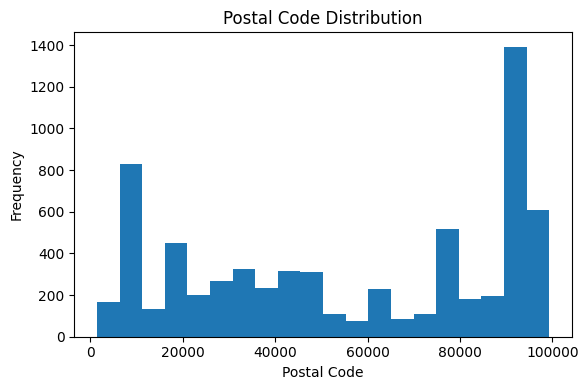

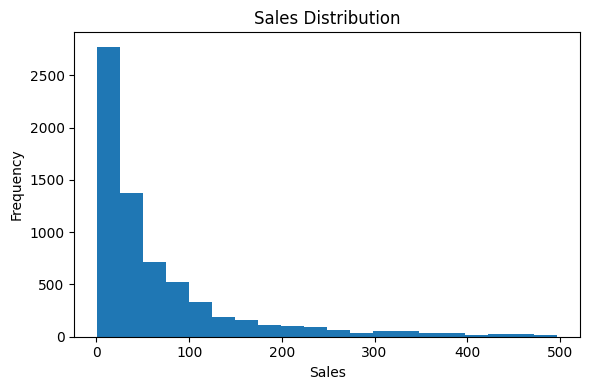

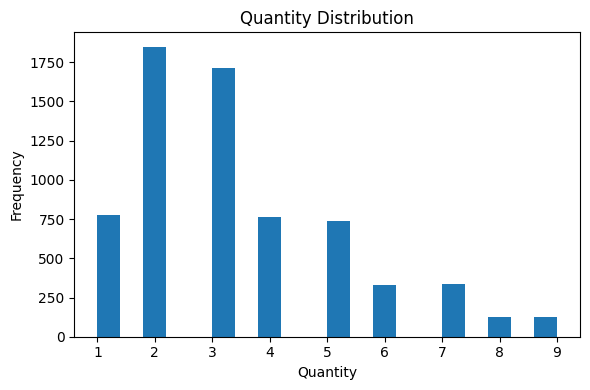

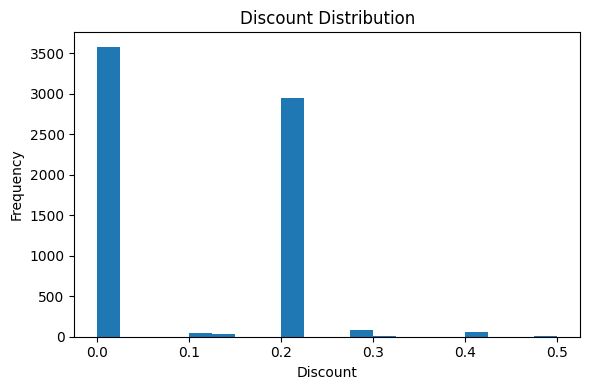

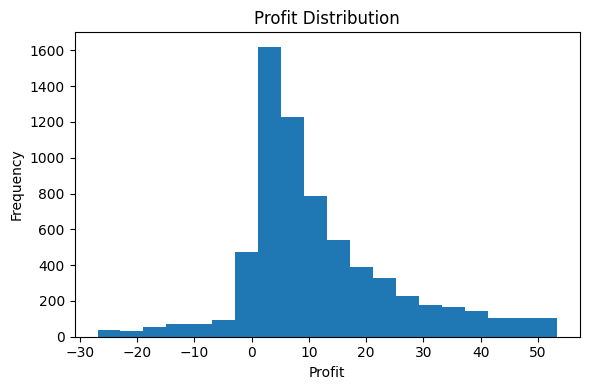

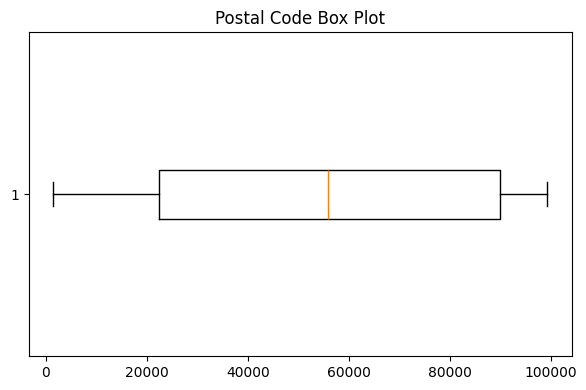

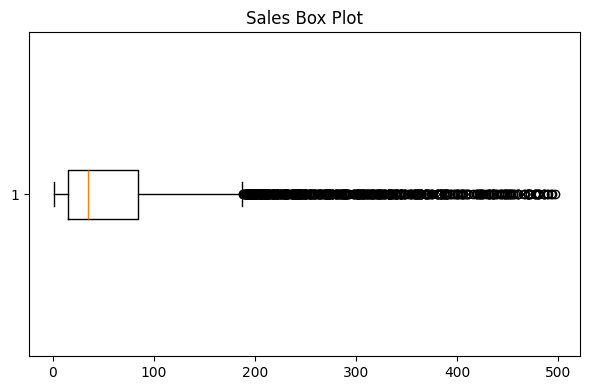

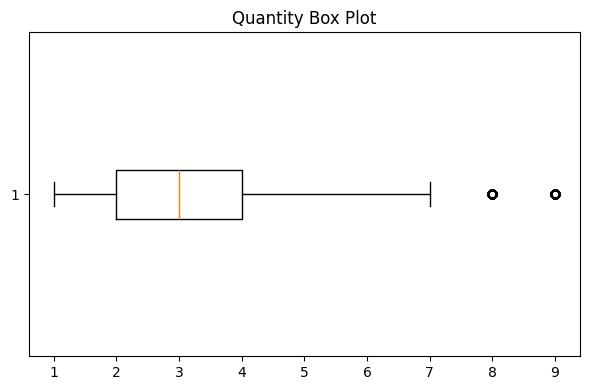

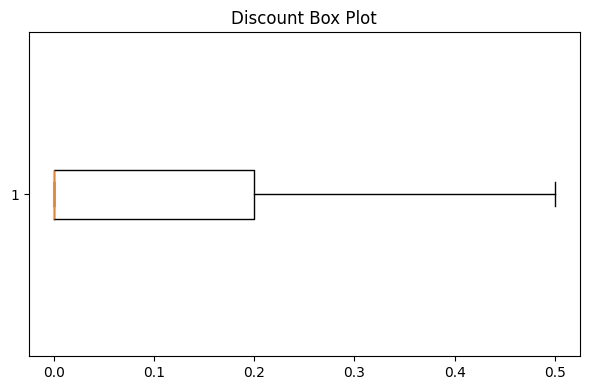

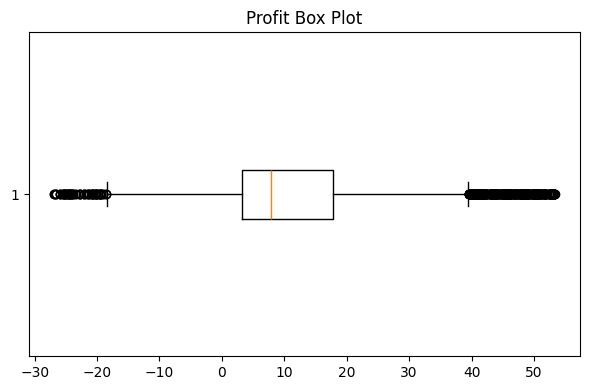

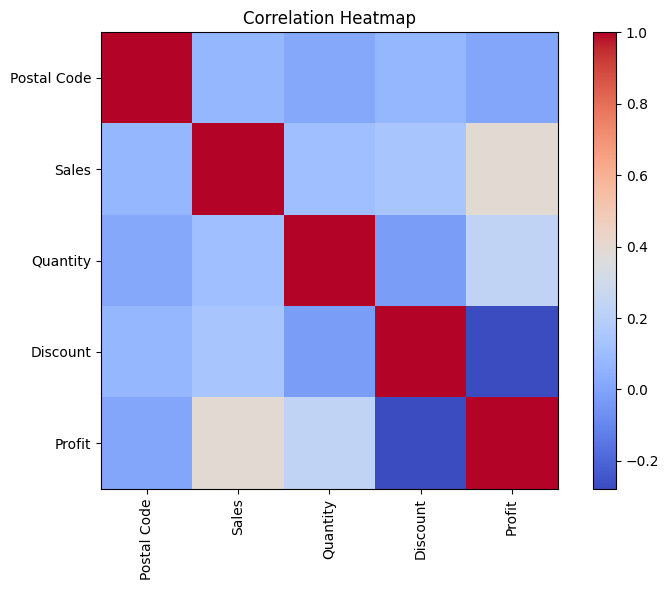

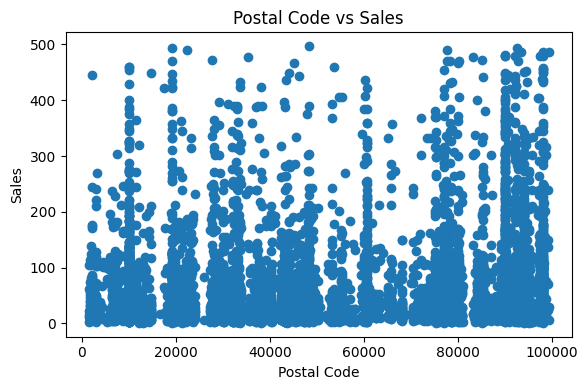

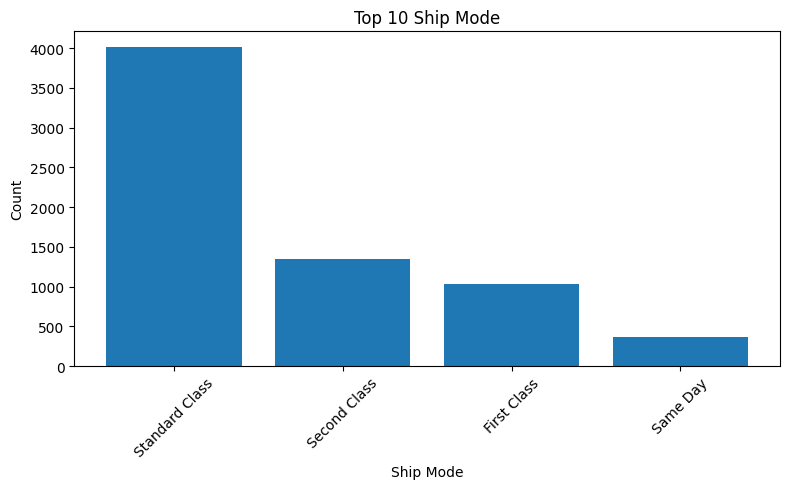


SUMMARY STATISTICS
        Postal Code        Sales     Quantity     Discount       Profit
count   6750.000000  6750.000000  6750.000000  6750.000000  6750.000000
mean   55724.171852    68.089541     3.374519     0.096339    11.673561
std    32803.255352    85.854284     1.869154     0.105154    13.524973
min     1453.000000     0.990000     1.000000     0.000000   -26.946000
25%    22304.000000    14.940000     2.000000     0.000000     3.241250
50%    55901.000000    34.860000     3.000000     0.000000     7.945000
75%    90036.000000    83.987000     4.000000     0.200000    17.745000
max    99301.000000   496.860000     9.000000     0.500000    53.346600

Cleaning and Visualization Completed Successfully!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/murlirathi/dataset/dataset.csv")

print("=" * 50)
print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

# Remove Duplicate Rows
duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"\nDuplicates Removed: {duplicates}")

# Fill Missing Values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Remove Outliers using IQR Method
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nDataset Shape After Cleaning:", df.shape)

# Save Cleaned Dataset
df.to_csv("cleaned_data.csv", index=False)

print("\nCleaned dataset saved as cleaned_data.csv")

# ------------------------------
# VISUALIZATIONS
# ------------------------------

# Histogram
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"{col}_histogram.png")
    plt.show()

# Box Plot
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"{col} Box Plot")
    plt.tight_layout()
    plt.savefig(f"{col}_boxplot.png")
    plt.show()

# Correlation Heatmap (Without Seaborn)
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(8,6))
    plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
    plt.colorbar()

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png")
    plt.show()

# Scatter Plot (First Two Numeric Columns)
if len(numeric_cols) >= 2:
    plt.figure(figsize=(6,4))
    plt.scatter(df[numeric_cols[0]], df[numeric_cols[1]])
    plt.xlabel(numeric_cols[0])
    plt.ylabel(numeric_cols[1])
    plt.title(f"{numeric_cols[0]} vs {numeric_cols[1]}")
    plt.tight_layout()
    plt.savefig("scatter_plot.png")
    plt.show()

# Bar Chart (First Categorical Column)
cat_cols = df.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    top = df[cat_cols[0]].value_counts().head(10)

    plt.figure(figsize=(8,5))
    plt.bar(top.index.astype(str), top.values)
    plt.xticks(rotation=45)
    plt.xlabel(cat_cols[0])
    plt.ylabel("Count")
    plt.title(f"Top 10 {cat_cols[0]}")
    plt.tight_layout()
    plt.savefig("bar_chart.png")
    plt.show()

# Summary Statistics
print("\nSUMMARY STATISTICS")
print(df.describe())

print("\nCleaning and Visualization Completed Successfully!")